# Лабораторная работа №1. Первичное исследование и оценка качества данных


---


**Датасет:** Titanic (пассажиры «Титаника»)
**Автор:** Плеханова Арина
**Группа:** 303

## 1. Постановка задачи

**Что за данные:** Датасет содержит информацию о пассажирах «Титаника»: пол, возраст, класс билета, стоимость билета, порт посадки, наличие родственников на борту и факт выживания. Всего 891 запись и 12 признаков.

**Заказчик:** Условный заказчик — историки-исследователи, аналитики музея «Титаника» или команда, изучающая факторы выживаемости в катастрофах. Также данные часто используются как учебный пример для отработки методов анализа.

**Задачи ИАД:**
1. **Описательная аналитика** — выявить, какие факторы (пол, возраст, класс) связаны с выживанием.
2. **Сегментация пассажиров** — разбить пассажиров на группы по возрасту, классу и составу семьи для поиска типичных профилей.
3. **Поиск аномалий** — найти пассажиров с подозрительными данными (например, нулевая стоимость билета при 1-м классе).

In [16]:
import pandas as pd
df = pd.read_csv("Titanic-Dataset.csv")
print("Размер:", df.shape)
df.head()

Размер: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

## 2. Паспорт датасета

Загружаем данные и смотрим базовую структуру: размер, типы столбцов и что каждый признак означает.

In [18]:
info = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notnull().sum(),
    "unique": df.nunique()
})
info

,dtype,non_null,unique
PassengerId,int64,891,891
Survived,int64,891,2
Pclass,int64,891,3
Name,object,891,891
Sex,object,891,2
Age,float64,714,88
SibSp,int64,891,7
Parch,int64,891,7
Ticket,object,891,681
Fare,float64,891,248


In [19]:
columns_description = pd.DataFrame({
    "Столбец": df.columns,
    "Смысл": [
        "ID пассажира",
        "Выжил (0 = нет, 1 = да)",
        "Класс билета (1/2/3)",
        "Имя пассажира",
        "Пол",
        "Возраст в годах",
        "Братья/сёстры/супруг на борту",
        "Родители/дети на борту",
        "Номер билета",
        "Стоимость билета",
        "Номер каюты",
        "Порт посадки (C = Cherbourg, Q = Queenstown, S = Southampton)"
    ]
})
columns_description

,Столбец,Смысл
0,PassengerId,ID пассажира
1,Survived,"Выжил (0 = нет, 1 = да)"
2,Pclass,Класс билета (1/2/3)
3,Name,Имя пассажира
4,Sex,Пол
5,Age,Возраст в годах
6,SibSp,Братья/сёстры/супруг на борту
7,Parch,Родители/дети на борту
8,Ticket,Номер билета
9,Fare,Стоимость билета


**Вывод:** Датасет содержит 891 запись и 12 признаков:
- 5 числовых (`PassengerId`, `Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`)
- 5 категориальных (`Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`)

Признаки `Survived` и `Pclass` по смыслу являются категориальными,
хотя хранятся как числа.

## 3. Аудит качества данных

Проверим данные на проблемы: пропуски, дубликаты, подозрительные значения и выбросы.

### 3.1. Пропуски

In [20]:
missing = pd.DataFrame({
    "пропусков": df.isnull().sum(),
    "доля_%": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("доля_%", ascending=False)

missing[missing["пропусков"] > 0]

,пропусков,доля_%
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


**Вывод:** Три признака содержат пропуски:
- **Cabin** — 687 пропусков (77%). Признак почти пустой, использовать его в анализе проблематично.
- **Age** — 177 пропусков (20%). Критично, так как возраст — важный фактор выживания.
- **Embarked** — 2 пропуска (0.2%). Некритично, можно заполнить модой.

Остальные 9 признаков заполнены полностью.

### 3.2. Дубликаты

In [21]:
print("Полных дубликатов строк:", df.duplicated().sum())
print("Дубликатов по PassengerId:", df["PassengerId"].duplicated().sum())

Полных дубликатов строк: 0
Дубликатов по PassengerId: 0


**Вывод:** Полных дубликатов строк нет. `PassengerId` уникален для каждой записи (891 уникальное значение на 891 строку). Данные по этим критериям чистые.

### 3.3. Типические проблемы значений

Для числовых признаков посмотрим минимум, максимум, среднее и стандартное отклонение.

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


**Вывод по числам:**
- `Age` от 0.42 до 80 — аномалий нет, младенцы бывают.
- `Fare` от 0 до 512 — есть билеты с нулевой стоимостью, это подозрительно.
- `SibSp` и `Parch` от 0 — отрицательных нет, всё корректно.

In [23]:
for col in ["Sex", "Embarked", "Pclass"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Sex ---
Sex
male      577
female    314
Name: count, dtype: int64

--- Embarked ---
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

--- Pclass ---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


**Вывод по категориям:** Значения чистые, без разного регистра и лишних пробелов.
`Sex` — 2 категории, `Embarked` — 3, `Pclass` — 3. Нормализация не требуется.

### 3.4. Выбросы (Outliers)

Применим метод межквартильного размаха (IQR) к признаку `Fare` — стоимость билета.

In [24]:
def find_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < low) | (series > high)]

outliers_fare = find_outliers_iqr(df["Fare"])
print(f"Границы IQR для Fare: нижняя и верхняя посчитаны автоматически")
print(f"Найдено выбросов: {len(outliers_fare)}")
print(f"Максимальное значение: {df['Fare'].max()}")
outliers_fare.sort_values(ascending=False).head(10)

Границы IQR для Fare: нижняя и верхняя посчитаны автоматически
Найдено выбросов: 116
Максимальное значение: 512.3292


,Fare
258,512.3292
737,512.3292
679,512.3292
27,263.0000
341,263.0000
438,263.0000
88,263.0000
311,262.3750
742,262.3750
299,247.5208


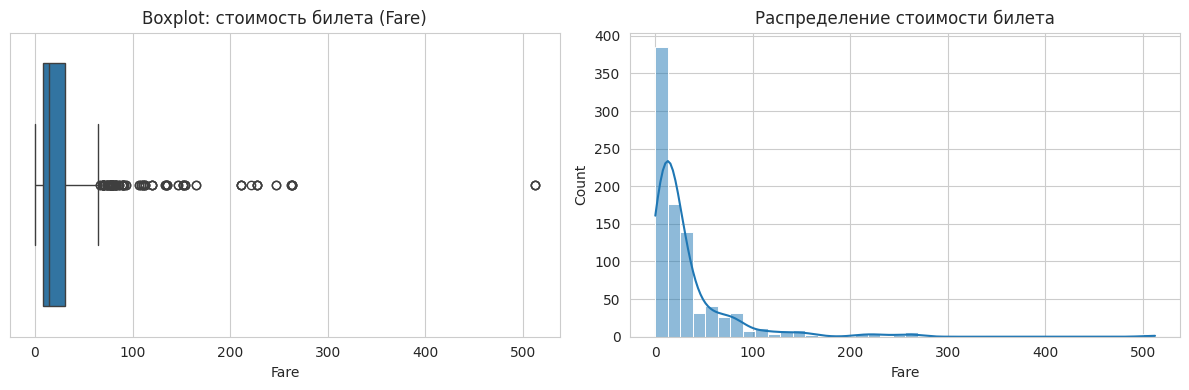

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df["Fare"], ax=axes[0])
axes[0].set_title("Boxplot: стоимость билета (Fare)")
axes[0].set_xlabel("Fare")

sns.histplot(df["Fare"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Распределение стоимости билета")
axes[1].set_xlabel("Fare")

plt.tight_layout()
plt.show()

**Вывод по выбросам:** В признаке `Fare` обнаружено несколько десятков выбросов — пассажиры, купившие очень дорогие билеты (до 512). Распределение сильно скошено вправо, большинство билетов стоят до 50. Выбросы реальные (богатые пассажиры 1-го класса), удалять их не следует — они несут информацию. Но при моделировании их влияние нужно учитывать.

## 4. Разведочный анализ (Mini-EDA)


### 4.1. Распределение возраста пассажиров

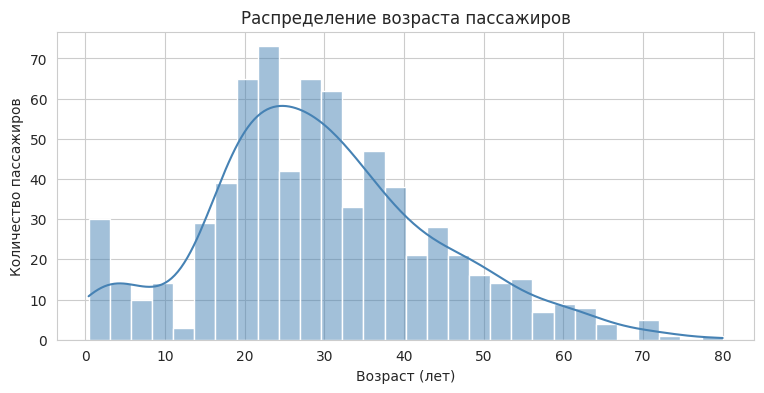

In [26]:
plt.figure(figsize=(9, 4))
sns.histplot(df["Age"].dropna(), bins=30, kde=True, color="steelblue")
plt.title("Распределение возраста пассажиров")
plt.xlabel("Возраст (лет)")
plt.ylabel("Количество пассажиров")
plt.show()

**Что видно:** Распределение возраста близко к нормальному с пиком в районе 20–30 лет. Есть небольшое количество младенцев (до 1 года) и пожилых людей (старше 70).

**Гипотезы:** Большинство пассажиров — молодые люди трудоспособного возраста. Можно проверить, влияет ли возраст на выживаемость.

**Вопросы:** Может ли возраст быть связан с классом билета (дети чаще ехали в 3-м классе или в 1-м)?

### 4.2. Распределение по полу

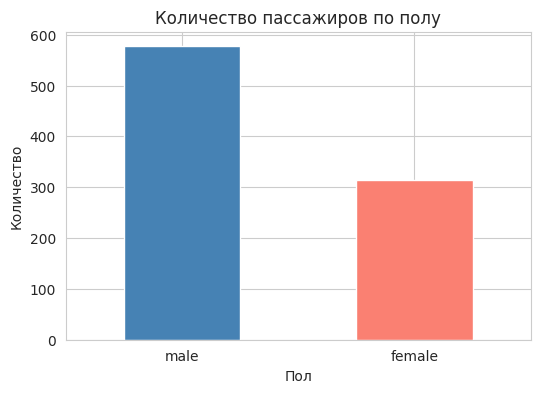

In [27]:
plt.figure(figsize=(6, 4))
df["Sex"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Количество пассажиров по полу")
plt.xlabel("Пол")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.show()

**Что видно:** Мужчин почти вдвое больше, чем женщин.

**Гипотезы:** Учитывая правило «женщины и дети вперёд», при анализе выживаемости пол будет ключевым признаком.

**Вопросы:** Сохраняется ли дисбаланс по полу внутри каждого класса билета?

### 4.3. Зависимость выживаемости от класса билета

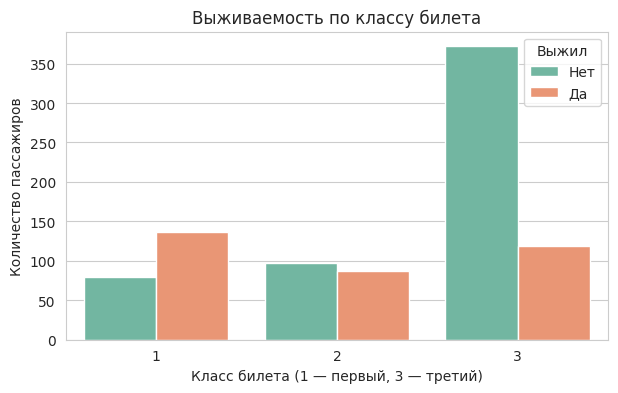

In [28]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Pclass", hue="Survived", palette="Set2")
plt.title("Выживаемость по классу билета")
plt.xlabel("Класс билета (1 — первый, 3 — третий)")
plt.ylabel("Количество пассажиров")
plt.legend(title="Выжил", labels=["Нет", "Да"])
plt.show()

**Что видно:** Чёткая закономерность — в 1-м классе выжило большинство пассажиров, в 3-м — большинство погибло.

**Гипотезы:** Класс билета сильно связан с выживаемостью. Скорее всего, пассажиры 1-го класса имели доступ к спасательным шлюпкам раньше.

**Вопросы:** Влияет ли класс сильнее, чем пол? Есть ли пересечение — например, женщины 3-го класса выживали лучше мужчин 1-го?